In [7]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from model import VGG16

In [8]:
# Config
CHECKPOINT = 'best_vgg16.pth'
TEST_DIR   = Path('dataset_5classes/test')
IMAGE_SIZE = 224
BATCH_SIZE = 32

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [9]:
# Transform (must match training)
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = test_dataset.classes
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')

Classes (5): ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Segmented Neutrophil']


In [10]:
# Load model
model = VGG16(num_classes=num_classes).to(device)
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()
print('Model loaded.')

Model loaded.


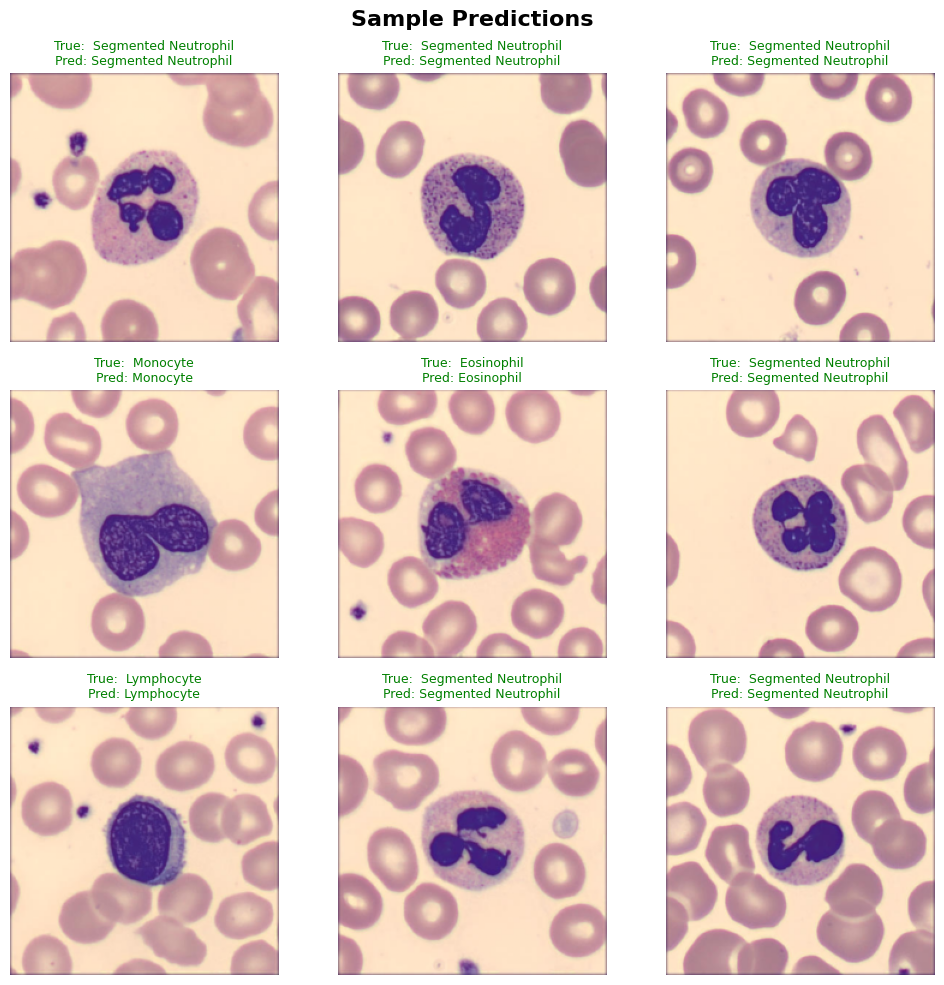

In [11]:
# 9-image sample grid
indices = random.sample(range(len(test_dataset)), 9)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('Sample Predictions', fontsize=16, fontweight='bold')

for ax, idx in zip(axes.flat, indices):
    img_tensor, true_label = test_dataset[idx]

    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(device))
        pred_label = torch.argmax(output, dim=1).item()

    # Denormalise so image colours look correct
    img_display = (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    color = 'green' if pred_label == true_label else 'red'
    ax.imshow(img_display)
    ax.set_title(
        f'True:  {class_names[true_label]}\nPred: {class_names[pred_label]}',
        color=color, fontsize=9
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

Test accuracy: 99.05%


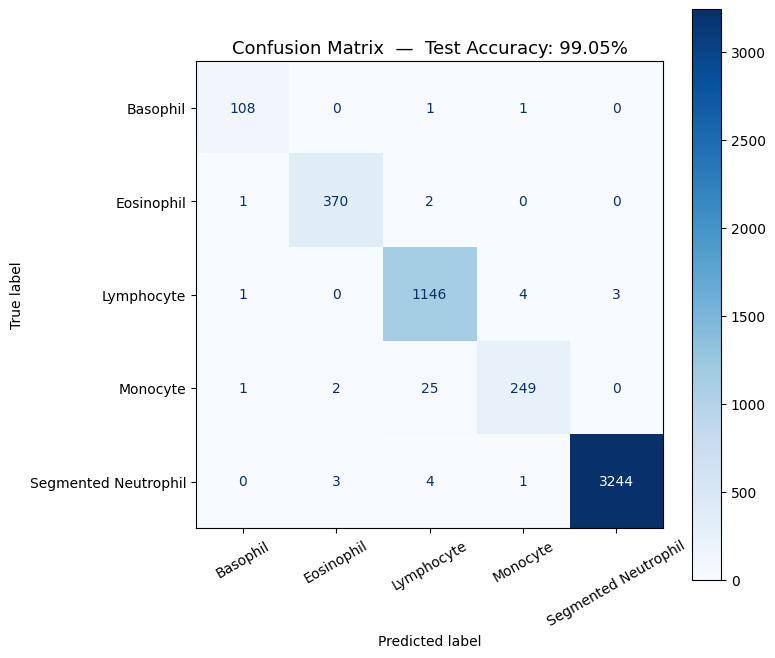

In [12]:
# Confusion matrix over full test set
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = torch.argmax(outputs, dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
accuracy = np.trace(cm) / cm.sum()
print(f'Test accuracy: {accuracy:.2%}')

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=30)
ax.set_title(f'Confusion Matrix  —  Test Accuracy: {accuracy:.2%}', fontsize=13)
plt.tight_layout()
plt.show()